# Content Recommendation System

In [2]:
import pandas as pd
import numpy as np
import json

import matplotlib as plt
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

In [3]:
# Loading data
path_project = "/home/hhyamamura/workspace/contentRecommendation/"
# Load all raw json files from  
df_genome_scores = pd.read_csv(path_project+"ml-25m/genome_scores.csv", encoding = 'utf8')
df_genome_tags = pd.read_csv(path_project+"ml-25m/genome_tags.csv", encoding = 'utf8')
# # As links are the sufix to the URL 
# https://movielens.org/movies/<movieId>
# http://www.imdb.com/title/<imdbId>
# https://www.themoviedb.org/movie/<tmdbId>
# it is a metadata not useful for the purpose of this work
# df_links = pd.read_csv(path_project+"ml-25m/links.csv", encoding = 'utf8', sep=',', quotechar='"',
#                    skipinitialspace=True,)
df_movies = pd.read_csv(path_project+"ml-25m/movies.csv", encoding = 'utf8')
df_ratings = pd.read_csv(path_project+"ml-25m/ratings.csv", encoding = 'utf8')
df_tags = pd.read_csv(path_project+"ml-25m/tags.csv", encoding = 'utf8', sep=',', quotechar='"',
                   skipinitialspace=True,)
# df_genome_scores- movieId,tagId,relevance
# df_genome_tags- tagId,tag
# df_links- movieId,imdbId,tmdbId
# df_movies- movieId,title,genres
# df_ratings- userId,movieId,rating,timestamp
# df_tags- userId,movieId,tag,timestamp

Let's see the data distribution  
  
## Exploratory Data Analisys (EDA)

In [4]:
display(df_movies.isnull().sum())
display(df_ratings.isnull().sum())
display(df_tags.isnull().sum())

movieId    0
title      0
genres     0
dtype: int64

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

userId        0
movieId       0
tag          16
timestamp     0
dtype: int64

In [5]:
display(df_movies.describe())
display(df_ratings.describe())
display(df_tags.describe())

,movieId
count,62423.000000
mean,122220.387646
std,63264.744844
min,1.000000
25%,82146.500000
50%,138022.000000
75%,173222.000000
max,209171.000000


,userId,movieId,rating,timestamp
count,2.500010e+07,2.500010e+07,2.500010e+07,2.500010e+07
mean,8.118928e+04,2.138798e+04,3.533854e+00,1.215601e+09
std,4.679172e+04,3.919886e+04,1.060744e+00,2.268758e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,4.051000e+04,1.196000e+03,3.000000e+00,1.011747e+09
50%,8.091400e+04,2.947000e+03,3.500000e+00,1.198868e+09
75%,1.215570e+05,8.623000e+03,4.000000e+00,1.447205e+09
max,1.625410e+05,2.091710e+05,5.000000e+00,1.574328e+09


,userId,movieId,timestamp
count,1.093360e+06,1.093360e+06,1.093360e+06
mean,6.759022e+04,5.849276e+04,1.430115e+09
std,5.152114e+04,5.968731e+04,1.177384e+08
min,3.000000e+00,1.000000e+00,1.135429e+09
25%,1.520400e+04,3.504000e+03,1.339262e+09
50%,6.219900e+04,4.594000e+04,1.468929e+09
75%,1.136420e+05,1.029030e+05,1.527402e+09
max,1.625340e+05,2.090630e+05,1.574317e+09


In [6]:
df_ratings['userId'].unique().shape

(162541,)

In [7]:
# Aggregate the total number of ratings per userId and rename the column to 'qtyRatings'
ratings_per_user = df_ratings.groupby('userId').size().reset_index(name='qtyRatings')

# Sort the userId in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)
display(ratings_per_user_sorted)

,userId,qtyRatings
72314,72315,32202
80973,80974,9178
137292,137293,8913
33843,33844,7919
20054,20055,7488
...,...,...
64554,64555,20
64416,64417,20
64425,64426,20
50,51,20


As the user with higher values are too high, we'll see how mean, median and mode are so that we can get a glimpse of its distribution

In [8]:
# Calculate the mean, median and mode
mean_value = ratings_per_user_sorted['qtyRatings'].mean()
print("Mean: {}".format(mean_value))

median_value = ratings_per_user_sorted['qtyRatings'].median()
print("Median: {}".format(median_value))

mode_value = ratings_per_user_sorted['qtyRatings'].mode()
print("Mode: {}".format(mode_value))

Mean: 153.80793153727367
Median: 71.0
Mode: 0    20
Name: qtyRatings, dtype: int64


This is a right-skewed distribution

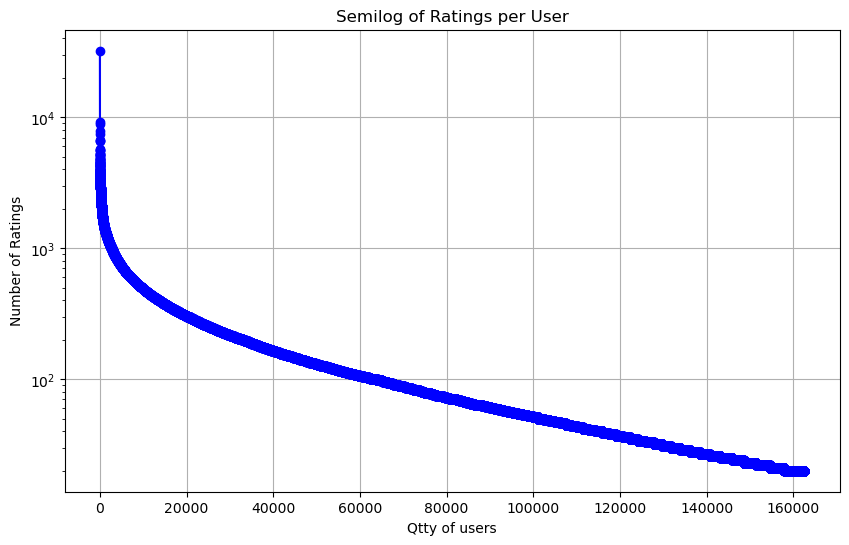

In [9]:
x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the userId in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.semilogy(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('Semilog of Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

There are different ways to trim the outliers, each one with pros and cons, as it does not follow a normal distribution and is a very right-skewed, I'll choose Inter Quartile Range (IQR), cutting by k=1.5, but still leaving `k` as parameter for a Tukey's Fences  
  
Now, to the outliers trimmings...

In [10]:
# Extract the 'qtyRatings' column
data = ratings_per_user_sorted['qtyRatings']

# Calculate the quartiles and interquartile range (IQR)
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# Calculate the median
median = np.median(data)

# Calculate the minimum and maximum values
minimum = np.min(data)
maximum = np.max(data)

# Calculate the lower and upper bounds for outliers
k = 2.5 # When k = 1.5 Tukey’s Fences becomes IQR
lower_bound = Q1 - k * IQR
upper_bound = Q3 + k * IQR

# Identify the outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]

# Print the statistics
print(f"Minimum: {minimum}")
print(f"Maximum: {maximum}")
print(f"Median: {median}")
print(f"1st Quartile (Q1): {Q1}")
print(f"3rd Quartile (Q3): {Q3}")
print(f"Interquartile Range (IQR): {IQR}")
print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")

# Identify outliers
df_user_outliers = ratings_per_user_sorted[(ratings_per_user_sorted['qtyRatings'] < lower_bound) |
                                            (ratings_per_user_sorted['qtyRatings'] > upper_bound)
                                            ]

# Print out the userIds that are outliers
print("Outlier userIds (sorted by qty ratings):\n", df_user_outliers.sort_values(by='qtyRatings'))

Minimum: 20
Maximum: 32202
Median: 71.0
1st Quartile (Q1): 36.0
3rd Quartile (Q3): 162.0
Interquartile Range (IQR): 126.0
Lower Bound for Outliers: -279.0
Upper Bound for Outliers: 477.0
Outlier userIds (sorted by qty ratings):
         userId  qtyRatings
11232    11233         478
52511    52512         478
88407    88408         478
56080    56081         478
81220    81221         478
...        ...         ...
20054    20055        7488
33843    33844        7919
137292  137293        8913
80973    80974        9178
72314    72315       32202

[10413 rows x 2 columns]


In [11]:
# remove all df_user_outliers
df_ratings = df_ratings[~df_ratings['userId'].isin(df_user_outliers['userId'])]
df_tags = df_tags[~df_tags['userId'].isin(df_user_outliers['userId'])]

Checking again the cut off outliers

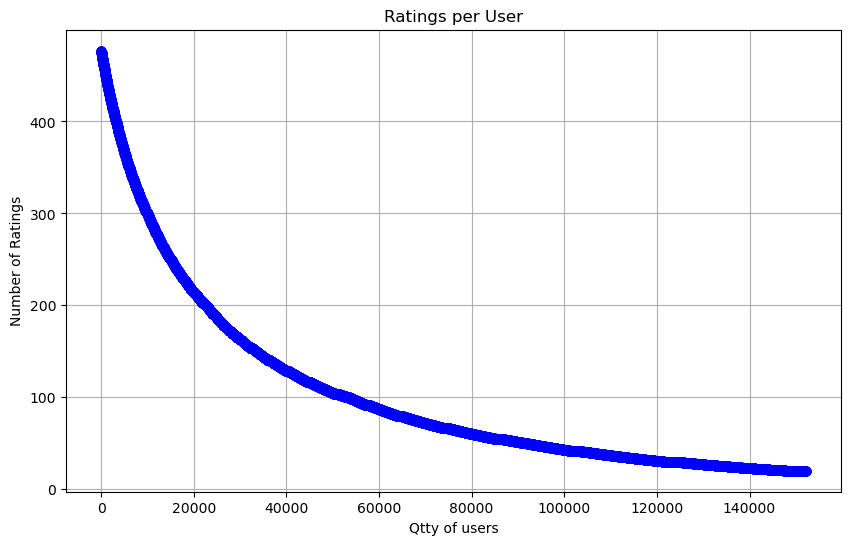

In [12]:
# Aggregate the total number of ratings per userId and rename the column to 'qtyRatings'
ratings_per_user = df_ratings.groupby('userId').size().reset_index(name='qtyRatings')

# Sort the userId in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the userId in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

In [13]:
display(x_data.shape)
display(qty_ratings.shape)

(152128,)

(152128,)

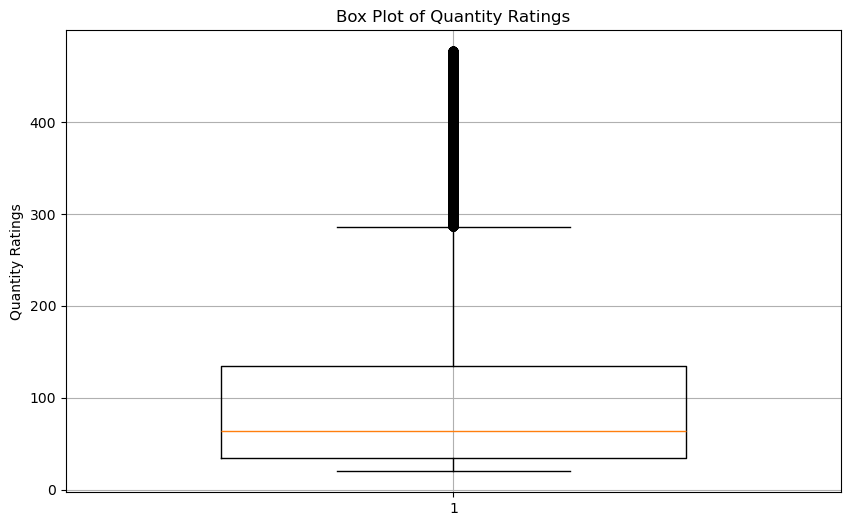

In [14]:
# Plotting the box plot using matplotlib
plt.figure(figsize=(10, 6))

plt.boxplot(qty_ratings, widths=0.6)
plt.ylabel('Quantity Ratings')
plt.title('Box Plot of Quantity Ratings')
plt.grid(True)
plt.show()

Leaving behind the monolog graph, now let's see the movie distributions

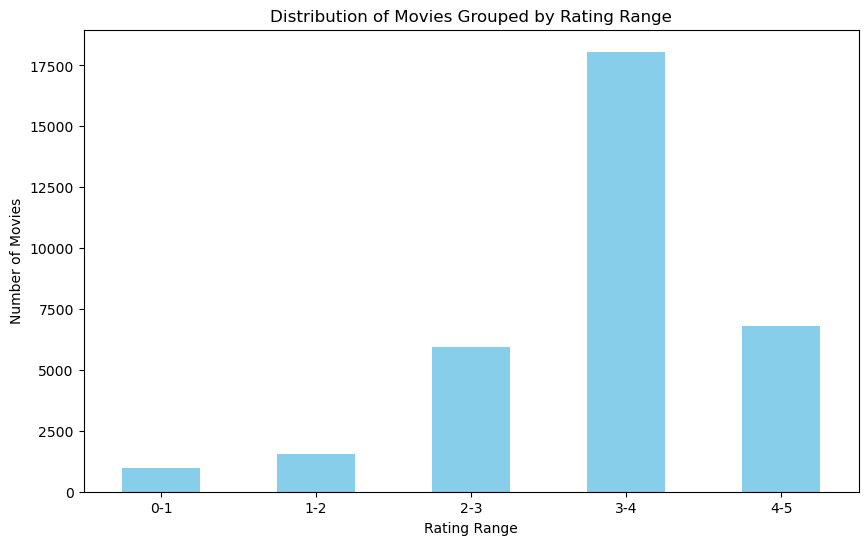

In [15]:
# Group by ID and calculate the mean rating
mean_ratings = df_ratings.groupby('movieId')['rating'].mean().reset_index()

# Define bins for rating ranges
bins = [0, 1, 2, 3, 4, 5] 
labels = ['0-1', '1-2', '2-3', '3-4', '4-5']

# Add a new column to categorize mean ratings into bins
mean_ratings['rating_range'] = pd.cut(mean_ratings['rating'], bins=bins, labels=labels, right=False)

# Group by the rating range and count the number of movies in each range
rating_distribution = mean_ratings['rating_range'].value_counts().sort_index()

# Plot the distribution
plt.figure(figsize=(10, 6))
rating_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution of Movies Grouped by Rating Range')
plt.xlabel('Rating Range')
plt.ylabel('Number of Movies')
plt.xticks(rotation=0)
plt.show()

There might be a hint in here: could it be users are prone to leave the movie without ratings when they consider it a mediocre movie?  
Having less ratings in lower scores may impact when modeling low-score movies  

Let's check ratings per genre

In [16]:
# Explode the genres column to have one genre per row
df_movies_exploded = df_movies.assign(genres=df_movies['genres'].str.split('|')).explode('genres')

# Count the number of movies per genre
genre_counts = df_movies_exploded['genres'].value_counts()

# Merge the movies and ratings dataframes
df_merged = pd.merge(df_movies_exploded, df_ratings, on='movieId')

# Calculate the average rating for each genre
average_ratings = df_merged.groupby('genres')['rating'].mean()
median_ratings = df_merged.groupby('genres')['rating'].median()
mode_ratings = df_merged.groupby('genres')['rating'].agg(pd.Series.mode)

# Reorder the genres to have the same order in both plots
genres_order = genre_counts.index

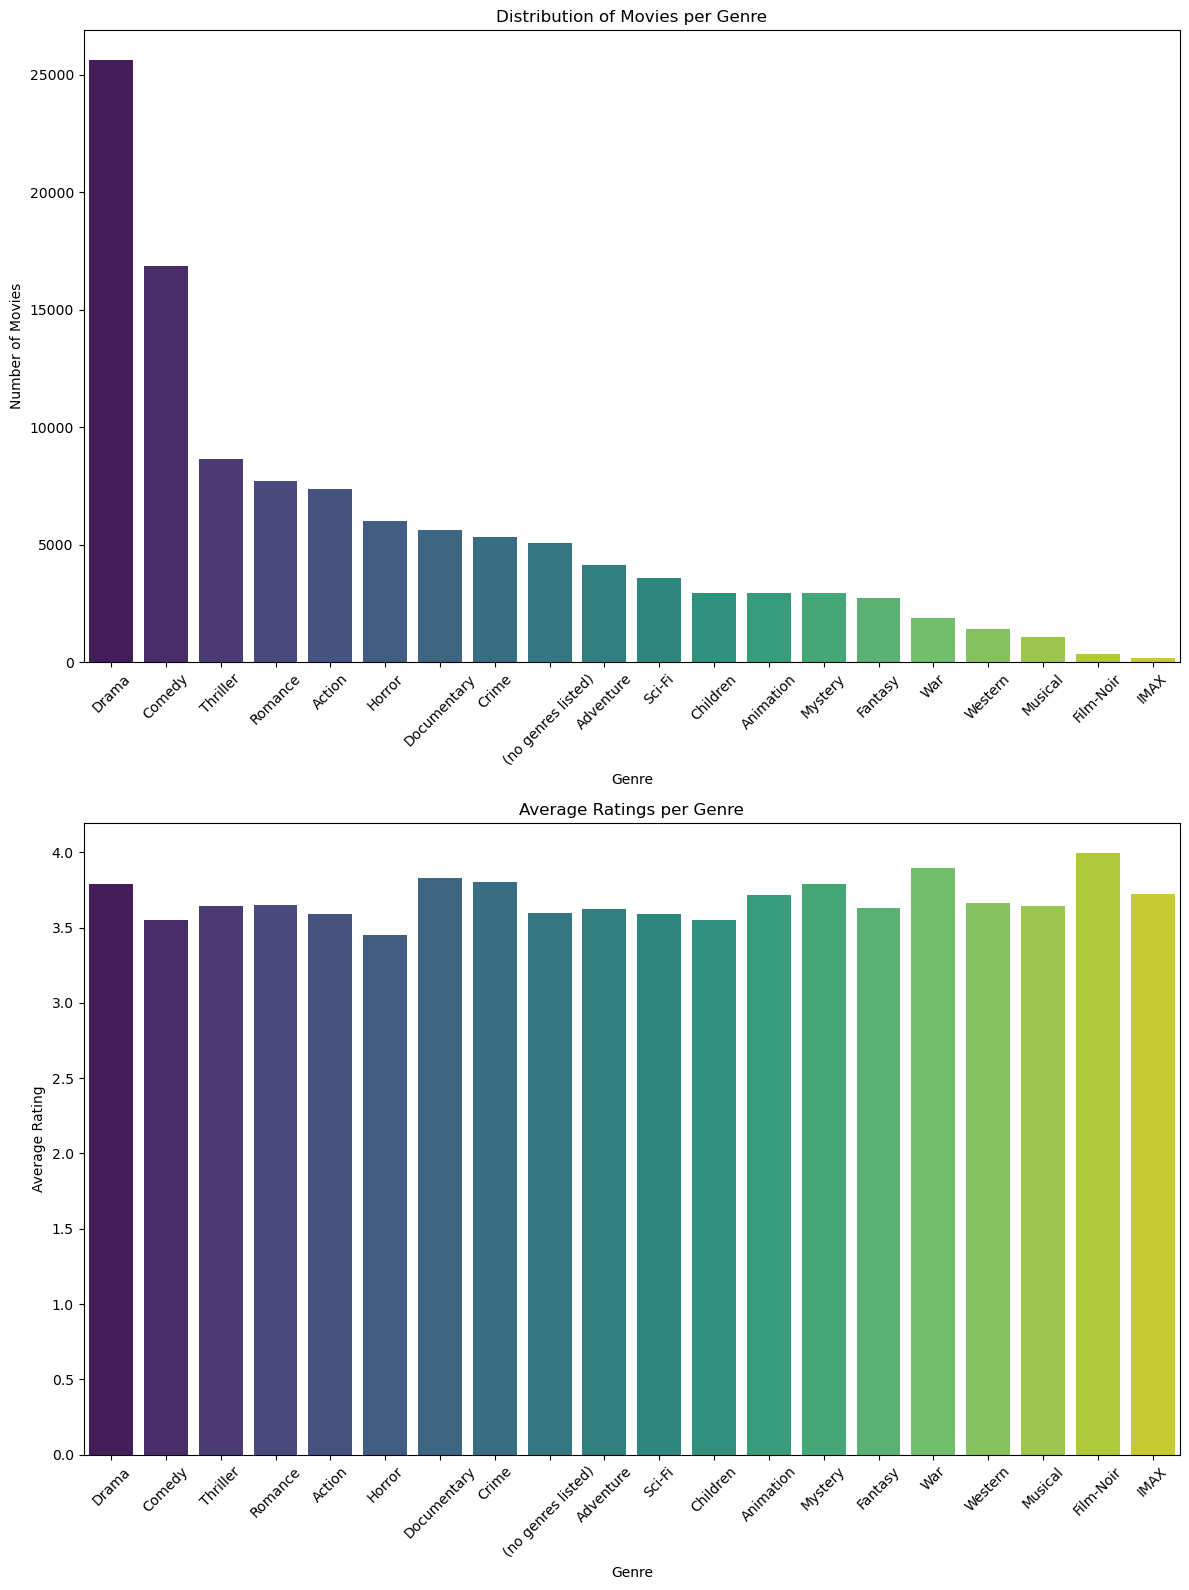

In [17]:
# Plot graphs in the same figure
fig, axes = plt.subplots(2, 1, figsize=(12, 16))

# Plot the distribution of movies per genre
sns.barplot(x=genres_order, y=genre_counts[genres_order], palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Movies per Genre')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Number of Movies')
axes[0].tick_params(axis='x', rotation=45)

# Plot the average ratings per genre
sns.barplot(x=genres_order, y=average_ratings[genres_order], palette='viridis', ax=axes[1])
axes[1].set_title('Average Ratings per Genre')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [18]:
# Merge movies and ratings dataframes on 'movieId'
df_merged = pd.merge(df_movies, df_ratings, on='movieId')

# Split genres and explode into separate rows
df_merged['genres'] = df_merged['genres'].str.split('|')
df_exploded = df_merged.explode('genres')

# Group by genre and calculate the required statistics
genre_stats = df_exploded.groupby('genres').agg(
    avg_rating=('rating', 'mean'),
    num_movies=('movieId', 'nunique'),
    total_ratings=('rating', 'count')
).reset_index()

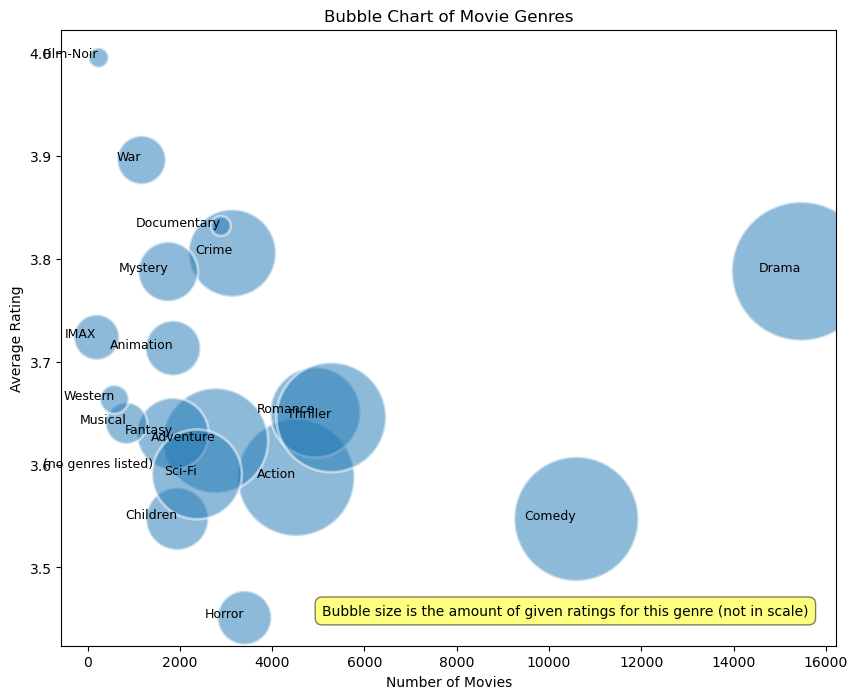

In [19]:
# # (df-df.mean())/df.std()
# norm = (genre_stats['total_ratings']-genre_stats['total_ratings'].mean())/genre_stats['total_ratings'].std()
# (df-df.min())/(df.max()-df.min())
norm = (genre_stats['total_ratings']-genre_stats['total_ratings'].min())/(genre_stats['total_ratings'].max()-genre_stats['total_ratings'].min())

# Plot the bubble chart
plt.figure(figsize=(10, 8))
bubble = plt.scatter(
    genre_stats['num_movies'], 
    genre_stats['avg_rating'], 
    s=norm*10000,  # Scale bubble sizes is too sm all, multiplied by a factor to be visible
    alpha=0.5,
    edgecolors="w",
    linewidth=2
)

# Add labels and title
plt.xlabel('Number of Movies')
plt.ylabel('Average Rating')
plt.title('Bubble Chart of Movie Genres')

# Add genre labels to the bubbles
for i in range(len(genre_stats)):
    plt.text(genre_stats['num_movies'][i], genre_stats['avg_rating'][i], 
             genre_stats['genres'][i], fontsize=9, ha='right')

# Add a custom legend
legend_text = "Bubble size is the amount of given ratings for this genre (not in scale)"
plt.annotate(
    legend_text,
    xy=(1, 0), xycoords='axes fraction',
    xytext=(-20, 20), textcoords='offset points',
    ha='right', va='bottom',
    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5)
)

plt.show()

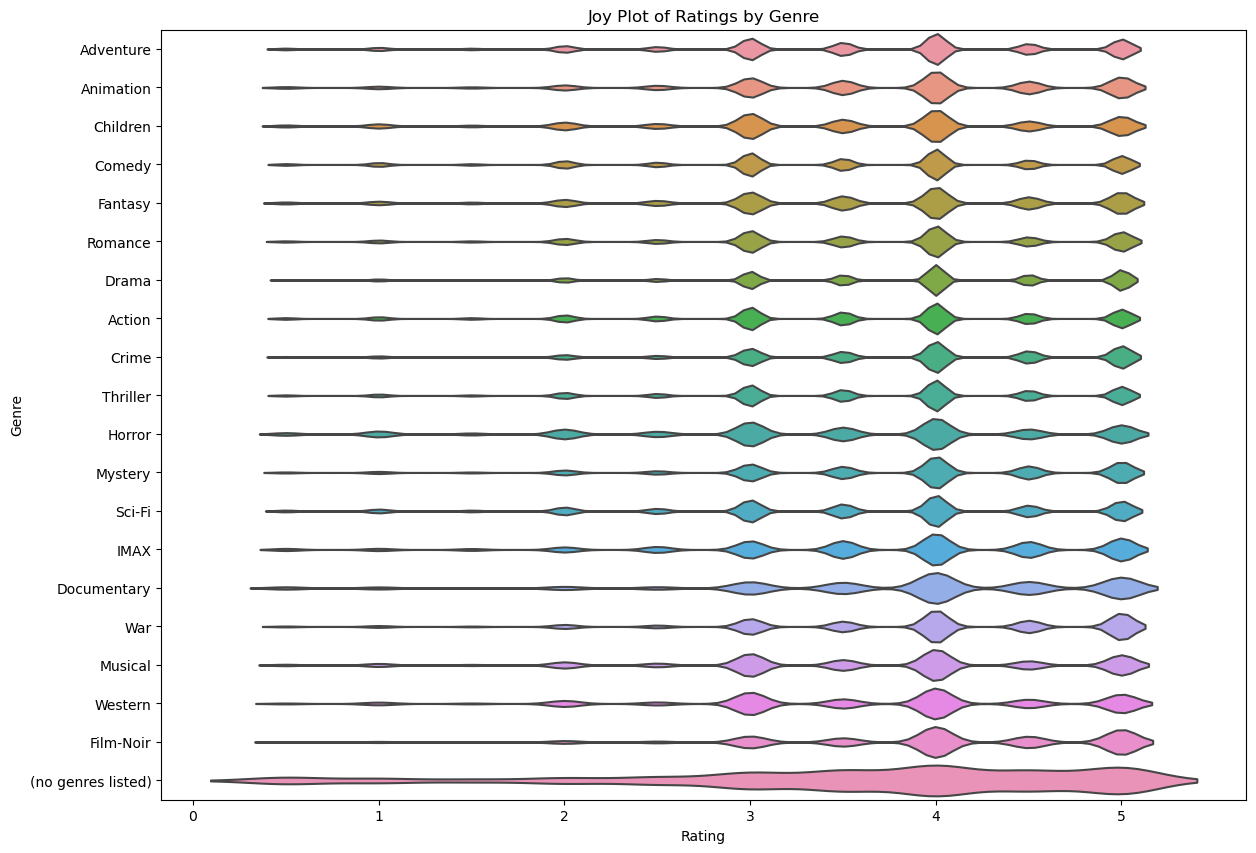

In [20]:
# Create the joy plot
plt.figure(figsize=(14, 10))
sns.violinplot(x='rating', y='genres', data=df_exploded, inner=None, scale='width')
plt.title('Joy Plot of Ratings by Genre')
plt.xlabel('Rating')
plt.ylabel('Genre')
plt.show()

## Preparing the array of genres
One movie may have different labels, eg 'Toy Story' can fit in Children, Animation and Adventure all at once  
In order to encode multiple genres in one single movie, we can create a boolean array of genres  

In [21]:
unique_genres = sorted(df_movies['genres'].str.split('|').explode().unique())

unique_genres

['(no genres listed)',
 'Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'IMAX',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western']

In [22]:
def generate_binary_matrix(genre_list):
    binaryList = []
    for genre in unique_genres:
        if genre in genre_list:
            binaryList.append(1)
        else:
            binaryList.append(0)
    return binaryList

# TODO
tmp_genres = df_movies['genres'].str.split('|')
result = tmp_genres.apply(lambda x: generate_binary_matrix(x))

df_movies['genres_binary'] = tmp_genres.apply(lambda x: generate_binary_matrix(x))

In [23]:
df_movies[(df_movies['title']=='Toy Story (1995)')][['genres', 'genres_binary']]

,genres,genres_binary
0,Adventure|Animation|Children|Comedy|Fantasy,"[0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."


In [24]:
chosen_movie = 'Star Wars: Episode I - The Phantom Menace (1999)'
for index, row in df_movies[(df_movies['title']==chosen_movie)][['genres_binary']].iterrows():
    print(f"Row {index}:")
    for i, genre in enumerate(unique_genres):
        if row['genres_binary'][i] == 1:
            print(genre)
    print("\n")

display(df_movies[(df_movies['title']==chosen_movie)])

Row 2537:
Action
Adventure
Sci-Fi




,movieId,title,genres,genres_binary
2537,2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Sci-Fi,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## Randomly grouping users to be the Training, Testing and Validation Sets

Let's split the non-outlier users into training, test and validation in 7 : 1.5 : 1.5  
The purpose for each group is to train; check the model and; remove few movies so that we can check if they appear as candidates of a suitable recommendation for these users

In [25]:
# Get unique users
unique_users = df_ratings['userId'].unique()

# Seed for reproducibility
SEED = 42

# Split users into train (70%), test (15%), and validation (15%)
training_ratio=0.7
train_users, temp_users = train_test_split(unique_users, test_size=(1-training_ratio), random_state=SEED)
test_users, val_users = train_test_split(temp_users, test_size=0.5, random_state=SEED)

# Create masks to filter the dataframes
train_mask = df_ratings['userId'].isin(train_users)
test_mask = df_ratings['userId'].isin(test_users)
val_mask = df_ratings['userId'].isin(val_users)

# Split the data
train_ratings = df_ratings[train_mask]
test_ratings = df_ratings[test_mask]
val_ratings = df_ratings[val_mask]

# KNN expects integers, I'm multiplying 20 to ratings so that the range is [0, 10, 20, 35, ..., 90, 100]
# df.loc[df['A'] > 2, 'B'] = new_val
# df.loc[df["bar"] > 5, "foo"]
train_ratings.loc[:, 'rating'] = train_ratings['rating'] #*20
test_ratings.loc[:, 'rating'] = test_ratings['rating'] #*20
val_ratings.loc[:, 'rating'] = val_ratings['rating'] #*20

print(f"Training set size: {len(train_ratings)}")
print(f"Testing set size: {len(test_ratings)}")
print(f"Validation set size: {len(val_ratings)}")

Training set size: 11013518
Testing set size: 2338573
Validation set size: 2346029


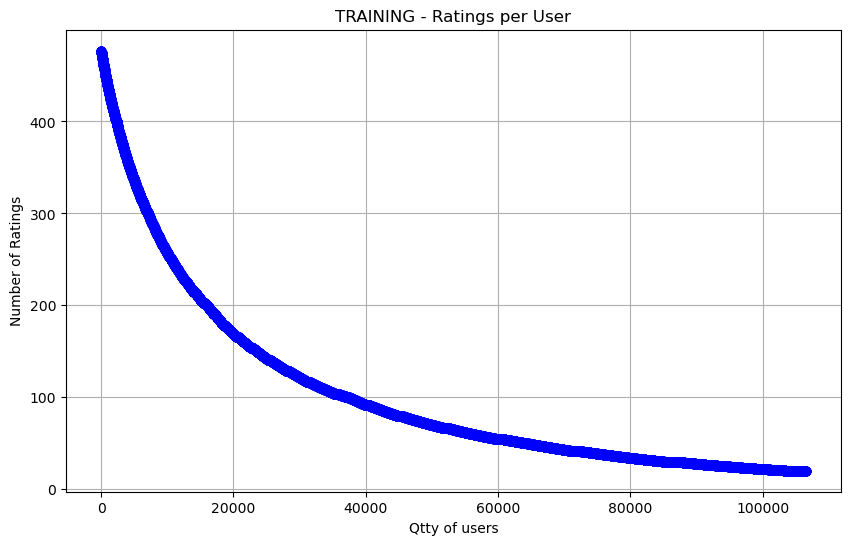

In [26]:
# Aggregate the total number of ratings per userId and rename the column to 'qtyRatings'
ratings_per_user = train_ratings.groupby('userId').size().reset_index(name='qtyRatings')

# Sort the userId in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the userId in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('TRAINING - Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

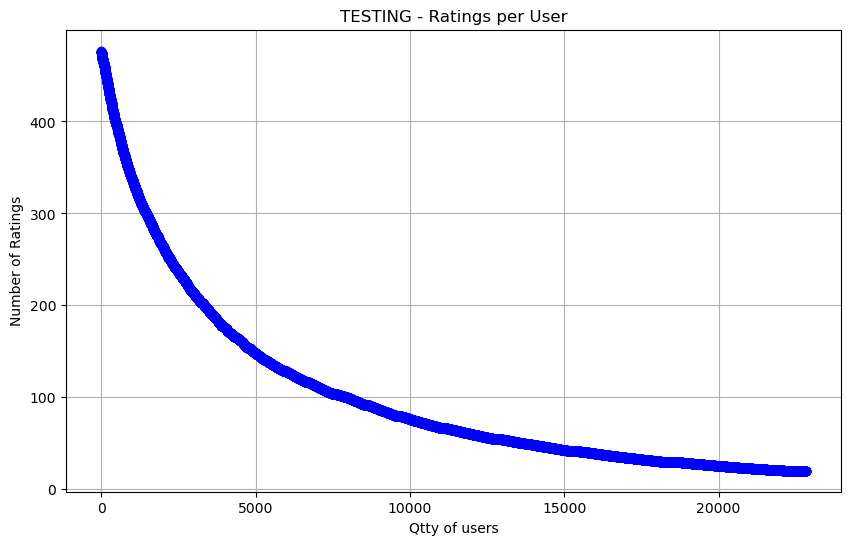

In [27]:
# Aggregate the total number of ratings per userId and rename the column to 'qtyRatings'
ratings_per_user = test_ratings.groupby('userId').size().reset_index(name='qtyRatings')

# Sort the userId in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the userId in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('TESTING - Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

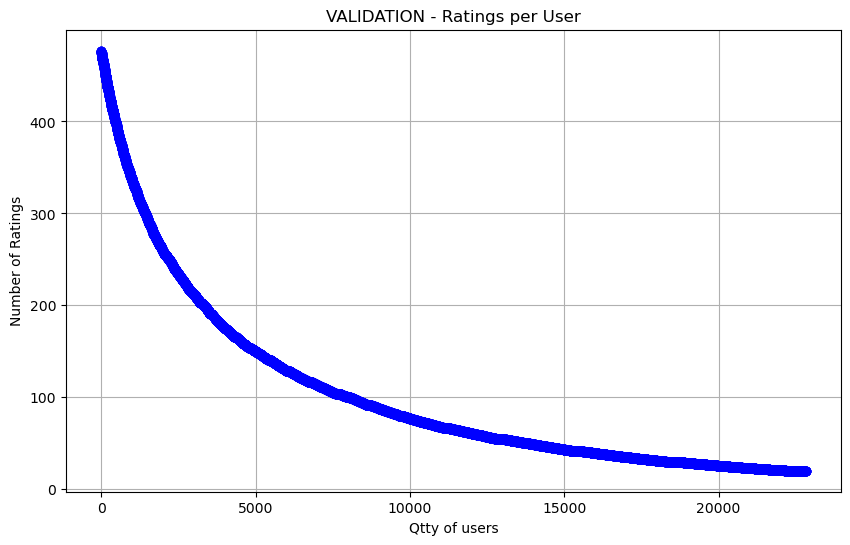

In [28]:
# Aggregate the total number of ratings per userId and rename the column to 'qtyRatings'
ratings_per_user = val_ratings.groupby('userId').size().reset_index(name='qtyRatings')

# Sort the userId in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the userId in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('VALIDATION - Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

In [29]:
display(ratings_per_user_sorted.max())
display(x_data.shape)

display(ratings_per_user_sorted.max())
display(x_data.shape)

userId        162540
qtyRatings       477
dtype: int64

(22820,)

userId        162540
qtyRatings       477
dtype: int64

(22820,)

In [30]:
df_mean_ratings = df_ratings.groupby('movieId')['rating'].mean().reset_index()
df_movies['avg_rating'] = df_mean_ratings['rating']
df_movies.head()

,movieId,title,genres,genres_binary,avg_rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",3.905748
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",3.317453
2,3,Grumpier Old Men (1995),Comedy|Romance,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3.213460
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",2.961662
4,5,Father of the Bride Part II (1995),Comedy,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3.144469


In [31]:
from scipy import spatial

def Similarity(movieId1, movieId2):
    a = df_movies.iloc[movieId1]
    b = df_movies.iloc[movieId2]

    genresA = a['genres_binary']
    genresB = b['genres_binary']

    # print('first movie: {}\t index: {}'.format(a['title'], movieId1))
    # display(genresA)
    # print('second movie: {}\t index: {}'.format(b['title'], movieId2))
    # display(genresB)
    genreDistance = spatial.distance.cosine(genresA, genresB)
    
    # wordsA = a['words_bin']
    # wordsB = b['words_bin']
    # wordsDistance = spatial.distance.cosine(directA, directB)
    return genreDistance # + wordsDistance
print(Similarity(5270, 2537))
print(Similarity(2537, 2539))

0.1339745962155614
1.0


In [32]:
import operator

def getNeighbors(baseMovie, K=10):
    # distances = []
    distances = df_movies[['movieId']]
    distances['dist'] = None

    for index, movie in df_movies.iterrows():
        if movie['movieId'] != baseMovie['movieId'].iloc[0]:
            dist = Similarity(int(baseMovie.index[0]), index)
            distances.at[index, 'dist'] = dist
    # Sort the distances DataFrame by the 'dist' column in ascending order
    distances = distances.sort_values(by='dist', ascending=True)
    
    # Reset the index of the DataFrame (optional, if you want a clean index)
    neighbors = distances.reset_index(drop=True)
    
    return neighbors.head(K)
    
def predict_score(name, K=100):
    # name = input('Enter a movie title: ')
    # name = 'Star Wars: Episode III - Revenge of the Sith (2005)'
    # What if film does not match?
    # TODO: Levenshtein distance?
    new_movie = df_movies[(df_movies['title']==name)]
    
    K = 100
    # avgRating = 0
    neighbors = getNeighbors(new_movie, K)
    print('\nRecommended Movies: \n')

    # Merge dataframes on movieId
    merged_df = pd.merge(neighbors, df_movies, on='movieId')
    
    # Select the relevant columns
    # display(new_movie[['movieId', 'title', 'genres_binary']])
    result_df = merged_df[['movieId', 'title', 'genres_binary', 'dist']]
    return result_df
    
    # print('\n')
    # avgRating = avgRating/K
    # print('The predicted rating for %s is: %f' %(new_movie['title'].values[0],avgRating))
    # print('The actual rating for %s is %f' %(new_movie['title'].values[0],new_movie['vote_average']))

pd.set_option('display.max_rows', 200)
# predict_score('Star Wars: Episode III - Revenge of the Sith (2005)')

In [33]:
# Picking a random userId to check if any of the predicted movies were watched by user
# Get unique userIds
unique_users = val_ratings['userId'].unique()

# Set the seed for reproducibility
np.random.seed(42)

# Select a random userId
random_user_id = np.random.choice(unique_users)

print(random_user_id)

112604


In [34]:
# Filter watched movies for this userId and sort by the ratings
sorted_ratings = val_ratings[val_ratings['userId'] == random_user_id].sort_values(by='rating', ascending=False)
sorted_ratings

,userId,movieId,rating,timestamp
17383052,112604,5060,5.0,975619690
17383035,112604,3527,5.0,967466999
17383036,112604,3578,5.0,967466856
17382844,112604,260,5.0,967466802
17382847,112604,296,5.0,967754421
...,...,...,...,...
17382981,112604,2412,1.0,967753871
17383037,112604,3593,1.0,967753845
17382861,112604,485,1.0,967753624
17382961,112604,2153,1.0,967753809


In [35]:
# Randomly pick a movieId
# Set the seed for reproducibility
np.random.seed(SEED)

random_movie_id = np.random.choice(sorted_ratings['movieId'])
random_movie = df_movies[df_movies["movieId"]==random_movie_id]
# random_movie['title'].iloc[0]

In [36]:
random_movie_id

1378

In [37]:
# Let's see similar movies from model
prediction = predict_score(random_movie['title'].iloc[0])

# ... and check how many of them matched with the movies that this same user had watched
# Filter prediction DataFrame to include only movies that are in sorted_ratings
movies_in_both = prediction[prediction['movieId'].isin(sorted_ratings['movieId'].unique())]

/tmp/ipykernel_746811/3236133725.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  distances['dist'] = None



Recommended Movies: 



In [38]:
prediction

,movieId,title,genres_binary,dist
0,2055,Hot Lead and Cold Feet (1978),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
1,110403,Border Feud (1947),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
2,105142,Barbed Wire (1952),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
3,4721,American Outlaws (2001),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
4,122310,Man of the East (1972),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
5,148184,Father Jackleg (1974),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
6,142340,Whisky and Ghosts (1976),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
7,202830,Lust in the Dust (1985),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
8,128249,The Great Scout & Cathouse Thursday (1976),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
9,124573,Sam Whiskey (1969),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0


In [39]:
movies_in_both

,movieId,title,genres_binary,dist
16,2701,Wild Wild West (1999),"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.133975
72,2951,"Fistful of Dollars, A (Per un pugno di dollari...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.183503


In [40]:
# What was the rating the user gave to the movie?
# sorted_ratings[(sorted_ratings['userId'] == random_user_id) & (sorted_ratings['movie_id' == random_movie_id])] #['rating']

sorted_ratings[(sorted_ratings['userId'] == random_user_id) & 
                             (sorted_ratings['movieId'] == random_movie_id)]['rating']

17382916    4.0
Name: rating, dtype: float64

In [41]:
print(sorted_ratings[(sorted_ratings['userId'] == random_user_id) & 
                             (sorted_ratings['movieId'] == 2701)]['rating']
     )

print(sorted_ratings[(sorted_ratings['userId'] == random_user_id) & 
                             (sorted_ratings['movieId'] == 2951)]['rating']
     )

17382999    1.0
Name: rating, dtype: float64
17383016    4.0
Name: rating, dtype: float64


In [42]:
movies_in_both.shape
sorted_ratings.shape

(219, 4)

In [43]:
# Let's see how it goes for other 20 different users
# Set the seed for reproducibility; I like Fibonacci because of reasons...
SEEDS = [1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946]

# Creating an empty DataFrame to store the recommended_predicted_ratio
recommended_predicted_ratio_for_user = pd.DataFrame(columns=['userId', 'ratio'])

# Iterate over each seed
for index, seed in enumerate(SEEDS):
    # Select a random userId
    np.random.seed(seed)
    random_user_id = np.random.choice(unique_users)
    # print(random_user_id)
    
    # Pick one movie from their already watched 
    random_movie_id = np.random.choice(sorted_ratings['movieId'])
    random_movie = df_movies[df_movies["movieId"]==random_movie_id]
    # Filter watched movies for this userId and sort by the ratings
    sorted_ratings = val_ratings[val_ratings['userId'] == random_user_id].sort_values(by='rating', ascending=False)

    # Let's see similar movies from model
    prediction = predict_score(random_movie['title'].iloc[0])
    # ... and check how many of them matched with the movies that this same user had watched
    # Filter prediction DataFrame to include only movies that are in sorted_ratings
    movies_in_both = prediction[prediction['movieId'].isin(sorted_ratings['movieId'].unique())]
    
    # Do the ratio between the predicted
    ratio = movies_in_both.shape[0] / sorted_ratings.shape[0]
    # Append to recommended_predicted_ratio
    recommended_predicted_ratio_for_user = pd.concat([recommended_predicted_ratio_for_user,
                                                      pd.DataFrame({'userId': random_user_id,
                                                                    'ratio': ratio},
                                                                  index=[index])
                                                     ])

/tmp/ipykernel_746811/3236133725.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  distances['dist'] = None



Recommended Movies: 



/tmp/ipykernel_746811/3403576055.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  recommended_predicted_ratio_for_user = pd.concat([recommended_predicted_ratio_for_user,
/tmp/ipykernel_746811/3236133725.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  distances['dist'] = None



Recommended Movies: 



/tmp/ipykernel_746811/3236133725.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  distances['dist'] = None


...


Recommended Movies: 



/tmp/ipykernel_746811/3236133725.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  distances['dist'] = None



Recommended Movies: 



/tmp/ipykernel_746811/3236133725.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  distances['dist'] = None



Recommended Movies: 



In [44]:
# Set the display precision for floats
pd.set_option('display.float_format', '{:.10f}'.format)

display(recommended_predicted_ratio_for_user)

,userId,ratio
0,1602,0.0000000000
1,18805,0.0000000000
2,42695,0.0000000000
3,21272,0.0000000000
4,32560,0.0000000000
5,2372,0.0000000000
6,109150,0.0000000000
7,83397,0.0000000000
8,33939,0.0000000000
9,44699,0.0000000000


## References:

IQR cut-off outliers:  
https://procogia.com/interquartile-range-method-for-reliable-data-analysis/  
https://medium.com/@ayeshasidhikha188/unveiling-outliers-exploring-z-score-and-iqr-methods-for-boxplots-67b0f3086720  

KNN
https://www.analyticsvidhya.com/blog/2020/08/recommendation-system-k-nearest-neighbors/